# 05 Club & Competition Context

Sprint 5 — left-join `player_performance_features` with `clubs` and `competitions` to attach club squad/stadium context and league/confederation context.

Output: `data/processed/player_market_value_dataset.parquet`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import INTERIM_DATA_DIR, METRICS_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.load_data import _resolve_raw_path, load_csv_file
from src.features import (
    add_club_competition_context,
    build_final_dataset_summary,
    prepare_clubs,
    prepare_competitions,
    save_final_dataset,
    save_final_dataset_summary,
    validate_final_dataset,
)

In [2]:
base = pd.read_parquet(INTERIM_DATA_DIR / 'player_performance_features.parquet')
clubs_raw = load_csv_file(_resolve_raw_path(RAW_DATA_DIR, 'clubs.csv'))
competitions_raw = load_csv_file(_resolve_raw_path(RAW_DATA_DIR, 'competitions.csv'))
print('base:', base.shape, '| clubs:', clubs_raw.shape, '| competitions:', competitions_raw.shape)

  loaded clubs.csv.gz: shape=(796, 17)
  loaded competitions.csv.gz: shape=(67, 11)
base: (476307, 76) | clubs: (796, 17) | competitions: (67, 11)


In [3]:
clubs = prepare_clubs(clubs_raw)
competitions = prepare_competitions(competitions_raw)
print('clubs prepared:', clubs.shape, '| competitions prepared:', competitions.shape)
clubs.head()

clubs prepared: (796, 15) | competitions prepared: (67, 10)


,club_id,club_code,name,domestic_competition_id,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,last_season,foreigners_ratio,national_team_players_ratio
0,10,arminia-bielefeld,Arminia Bielefeld,L1,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,2021,0.555556,0.148148
1,10004,paris-fc,Paris Football Club,FR1,31,28.7,17,54.8,8,Stade Jean Bouin,19904,€-72.30m,2025,0.548387,0.258065
2,10010,esporte-clube-bahia,Esporte Clube Bahia,BRA1,32,26.7,6,18.8,3,Arena Fonte Nova,47364,+€8.14m,2025,0.187500,0.093750
3,1003,leicester-city,Leicester City,GB1,29,25.9,17,58.6,9,King Power Stadium,32259,+€57.30m,2024,0.586207,0.310345
4,1005,us-lecce,Unione Sportiva Lecce,IT1,27,25.2,23,85.2,10,Ettore Giardiniero,31559,+€8.62m,2025,0.851852,0.370370


## Join + final_competition_id coalesce

In [4]:
enriched = add_club_competition_context(base, clubs, competitions)
validate_final_dataset(enriched, expected_rows=len(base))
print('final:', enriched.shape)
preview_cols = [c for c in ('player_id','player_name','valuation_date','club_name','final_competition_id','competition_name','market_value_in_eur','next_market_value_in_eur') if c in enriched.columns]
enriched[preview_cols].head(10)

final: (476307, 100)


,player_id,player_name,valuation_date,club_name,final_competition_id,competition_name,market_value_in_eur,next_market_value_in_eur
0,10,Miroslav Klose,2004-10-04,Società Sportiva Lazio S.p.A.,IT1,serie-a,7000000,9000000.0
1,10,Miroslav Klose,2005-01-07,Società Sportiva Lazio S.p.A.,IT1,serie-a,9000000,12000000.0
2,10,Miroslav Klose,2005-05-05,Società Sportiva Lazio S.p.A.,IT1,serie-a,12000000,15000000.0
3,10,Miroslav Klose,2005-09-30,Società Sportiva Lazio S.p.A.,IT1,serie-a,15000000,20000000.0
4,10,Miroslav Klose,2006-01-09,Società Sportiva Lazio S.p.A.,IT1,serie-a,20000000,30000000.0
5,10,Miroslav Klose,2006-07-15,Società Sportiva Lazio S.p.A.,IT1,serie-a,30000000,23000000.0
6,10,Miroslav Klose,2007-06-21,Società Sportiva Lazio S.p.A.,IT1,serie-a,23000000,20000000.0
7,10,Miroslav Klose,2008-06-04,Società Sportiva Lazio S.p.A.,IT1,serie-a,20000000,18000000.0
8,10,Miroslav Klose,2009-06-10,Società Sportiva Lazio S.p.A.,IT1,serie-a,18000000,12000000.0
9,10,Miroslav Klose,2009-08-30,Società Sportiva Lazio S.p.A.,IT1,serie-a,12000000,9000000.0


## Top competitions by row count

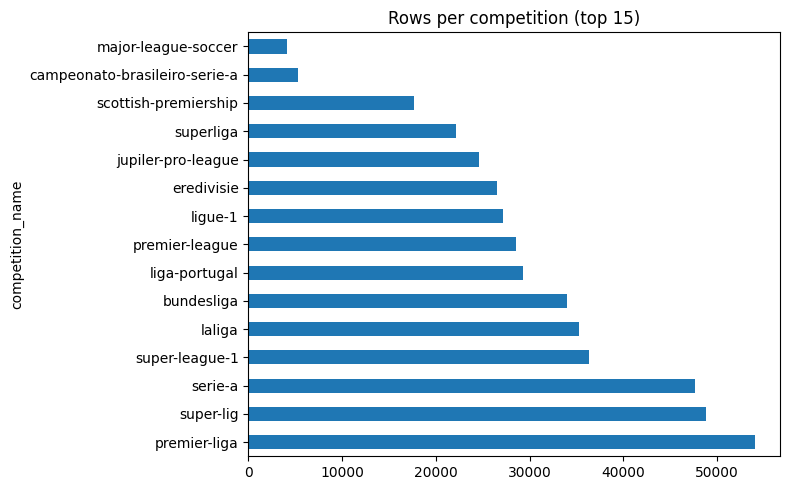

In [5]:
if 'competition_name' in enriched.columns:
    enriched['competition_name'].value_counts().head(15).plot(kind='barh', figsize=(8,5))
    plt.title('Rows per competition (top 15)')
    plt.tight_layout()
    plt.show()

## Persist artefacts

In [6]:
save_final_dataset(enriched, PROCESSED_DATA_DIR / 'player_market_value_dataset.parquet')
summary = build_final_dataset_summary(enriched)
save_final_dataset_summary(summary, METRICS_DIR / 'final_dataset_summary.json')
summary

Final dataset written to C:\football_market_value-dl\data\processed\player_market_value_dataset.parquet
Final summary written to C:\football_market_value-dl\reports\metrics\final_dataset_summary.json


{'rows': 476307,
 'columns': 100,
 'unique_players': 30637,
 'min_valuation_date': '2000-01-20',
 'max_valuation_date': '2025-12-19',
 'target_median': 600000.0,
 'target_mean': 2677953.313722032,
 'target_max': 200000000.0,
 'unique_clubs': 2750,
 'unique_competitions': 32,
 'missing_final_competition_id_pct': 1.08,
 'missing_club_name_pct': 4.34,
 'club_squad_size_missing_pct': 4.34,
 'club_average_age_missing_pct': 9.33,
 'club_stadium_seats_missing_pct': 4.34,
 'competition_name_missing_pct': 1.08,
 'top_20_competitions': {'premier-liga': 54013,
  'super-lig': 48867,
  'serie-a': 47661,
  'super-league-1': 36287,
  'laliga': 35278,
  'bundesliga': 33966,
  'liga-portugal': 29317,
  'premier-league': 28527,
  'ligue-1': 27171,
  'eredivisie': 26517,
  'jupiler-pro-league': 24637,
  'superliga': 22115,
  'scottish-premiership': 17696,
  'campeonato-brasileiro-serie-a': 5342,
  'major-league-soccer': 4090,
  'saudi-pro-league': 3869,
  'pko-bp-ekstraklasa': 3833,
  'torneo-apertura': 